In [1]:
from pathlib import Path
import h5py
import numpy as np
import pandas as pd

base = Path('/Users/pinkhorse/Documents/GitHub/latinise/christianity_semantic_change/contextual_embeddings/output/single_word_embeddings')
h5_files = sorted(base.glob('*.h5'))

print(f'Found {len(h5_files)} HDF5 files:')
for f in h5_files:
    print(' -', f.name)

Found 106 HDF5 files:
 - berts_finetuned_full_with_metadata_altare.h5
 - berts_finetuned_full_with_metadata_ara.h5
 - berts_finetuned_full_with_metadata_basilica.h5
 - berts_finetuned_full_with_metadata_beatus.h5
 - berts_finetuned_full_with_metadata_caritas.h5
 - berts_finetuned_full_with_metadata_caro.h5
 - berts_finetuned_full_with_metadata_codex.h5
 - berts_finetuned_full_with_metadata_communico.h5
 - berts_finetuned_full_with_metadata_communio.h5
 - berts_finetuned_full_with_metadata_confessio.h5
 - berts_finetuned_full_with_metadata_confiteor.h5
 - berts_finetuned_full_with_metadata_conuersio.h5
 - berts_finetuned_full_with_metadata_conuerto.h5
 - berts_finetuned_full_with_metadata_credo.h5
 - berts_finetuned_full_with_metadata_culpa.h5
 - berts_finetuned_full_with_metadata_cultus.h5
 - berts_finetuned_full_with_metadata_deus.h5
 - berts_finetuned_full_with_metadata_disciplina.h5
 - berts_finetuned_full_with_metadata_dominus.h5
 - berts_finetuned_full_with_metadata_fidelis.h5
 - 

In [2]:
# Pick one file to inspect
path = base / 'berts_finetuned_full_with_metadata_dominus.h5'

if not path.exists() and h5_files:
    path = h5_files[0]

print('Using:', path)

Using: /Users/pinkhorse/Documents/GitHub/latinise/christianity_semantic_change/contextual_embeddings/output/single_word_embeddings/berts_finetuned_full_with_metadata_dominus.h5


In [3]:
with h5py.File(path, 'r') as f:
    group_names = list(f.keys())
    print('n_groups:', len(group_names))
    print('first 10 groups:', group_names[:10])

n_groups: 5558
first 10 groups: ['text_00010_sentence_00446', 'text_00011_sentence_00551', 'text_00011_sentence_01268', 'text_00011_sentence_01352', 'text_00011_sentence_01353', 'text_00014_sentence_00550', 'text_00014_sentence_00886', 'text_00015_sentence_00000', 'text_00015_sentence_00704', 'text_00018_sentence_00014']


In [4]:
with h5py.File(path, 'r') as f:
    group_names = list(f.keys())
    gname = group_names[0]
    g = f[gname]

    print('group:', gname)
    print('n_matched_words:', g.attrs.get('n_matched_words'))

    attr_items = {k: g.attrs[k] for k in g.attrs.keys()}
    print('attribute keys:', list(attr_items.keys())[:20])

    emb_names = [k for k in g.keys() if k.endswith('_embedding')]
    print('embedding datasets in group:', len(emb_names))
    if emb_names:
        vec = g[emb_names[0]][:]
        print('first embedding dataset:', emb_names[0])
        print('shape:', vec.shape, 'dtype:', vec.dtype)
        print('first 8 values:', np.round(vec[:8], 4))

group: text_00010_sentence_00446
n_matched_words: 1
attribute keys: ['creator', 'date_avg', 'date_range_end', 'date_range_start', 'file', 'id', 'label_ridge_f1', 'label_ridge_youden', 'label_svm_f1', 'label_svm_youden', 'manual_label', 'n_matched_words', 'percentile__ridge_logit', 'percentile_svm_logit', 'prediction_source', 'prob_ridge', 'prob_svm', 'score_ridge_logit', 'score_svm_logit', 'sentence_char_end']
embedding datasets in group: 1
first embedding dataset: word_0000_embedding
shape: (768,) dtype: float32
first 8 values: [ 0.6467 -0.2278  0.2079 -0.2538 -1.3009  0.1269 -0.2227 -0.147 ]


In [5]:
# Build a compact table of first N groups
N = 50
rows = []

label_priority = ("label_ridge_youden", "label_ridge_f1", "label_svm_youden", "label_svm_f1", "manual_label")

with h5py.File(path, 'r') as f:
    for gname in list(f.keys())[:N]:
        g = f[gname]
        label_value = next(
            (str(g.attrs.get(key)).strip() for key in label_priority if g.attrs.get(key) is not None and str(g.attrs.get(key)).strip()),
            'NA',
        )
        rows.append({
            'group': gname,
            'n_matched_words': int(g.attrs.get('n_matched_words', 0)),
            'file': g.attrs.get('file', ''),
            'sentence_text': str(g.attrs.get('sentence_text', ''))[:120],
            'date_range_end': g.attrs.get('date_range_end', 'NA'),
            'pred_label': label_value
        })

df = pd.DataFrame(rows)
df.head(15)

,group,n_matched_words,file,sentence_text,date_range_end,pred_label
0,text_00010_sentence_00446,1,lat_-0218_MQDQ-323.txt,Sangarinus scio iam hic aderit cum domino suo .,-200,non_christian
1,text_00011_sentence_00551,1,lat_-0218_MQDQ-321.txt,Mihin domino seruos tu suscenses ?,-191,non_christian
2,text_00011_sentence_01268,1,lat_-0218_MQDQ-321.txt,Aedium dominum lenonem Ballionem quaerito .,-191,non_christian
3,text_00011_sentence_01352,1,lat_-0218_MQDQ-321.txt,quid mercedis petasus hodie domino demeret ?,-191,non_christian
4,text_00011_sentence_01353,1,lat_-0218_MQDQ-321.txt,"Quid "" domino "" ?",-191,non_christian
5,text_00014_sentence_00550,1,lat_-0218_MQDQ-306.txt,"iam sequere sis , erum qui ludificas dictis de...",-184,non_christian
6,text_00014_sentence_00886,1,lat_-0218_MQDQ-306.txt,"Abin hinc a me , dignus domino seruos ?",-184,non_christian
7,text_00015_sentence_00000,1,lat_-0218_MQDQ-307.txt,"Hoc agite sultis , spectatores , nunciam , qua...",-184,non_christian
8,text_00015_sentence_00704,1,lat_-0218_MQDQ-307.txt,"Ego baiiolabo , tu , ut decet dominum , ante m...",-184,non_christian
9,text_00018_sentence_00014,1,lat_-0218_MQDQ-310.txt,"Fugitiuos ille , ut dixeram ante , huiius patr...",-184,christian


## PCA and t-SNE Preview
Sample embedding vectors from one HDF5 file, reduce dimensions, and visualize potential clustering structure.

sampled vectors: (3000, 768)
time_slice distribution in sample: Counter({'post_180': 2685, 'pre_180': 315})
PCA input matrix: 3,000 embeddings × 768 dimensions
PCA reduced to 50 components, retaining 72.1% of variance.
PC1 + PC2 (left plot) explain 34.3% of variance.
t-SNE baseline perplexity: 20 (target=20, roughly local neighborhood size)

Seed stability summary (pre_180/post_180 subset):
 seed  silhouette_tsne
    2         0.015294
    0         0.016146
    1         0.016299
   99         0.017937
   42         0.018889
Median silhouette across seeds: 0.0163
Plot seed selected (closest to median silhouette): 1

Seed stability summary (pre_180/post_180 subset):
 seed  silhouette_tsne
    2         0.015294
    0         0.016146
    1         0.016299
   99         0.017937
   42         0.018889
Median silhouette across seeds: 0.0163
Plot seed selected (closest to median silhouette): 1


/var/folders/jd/xvx5v5v90h9cw8nds75nyybw0000gn/T/ipykernel_72323/3248279081.py:135: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  fallback_cmap = plt.cm.get_cmap("tab10", max(1, len(unique_labels)))


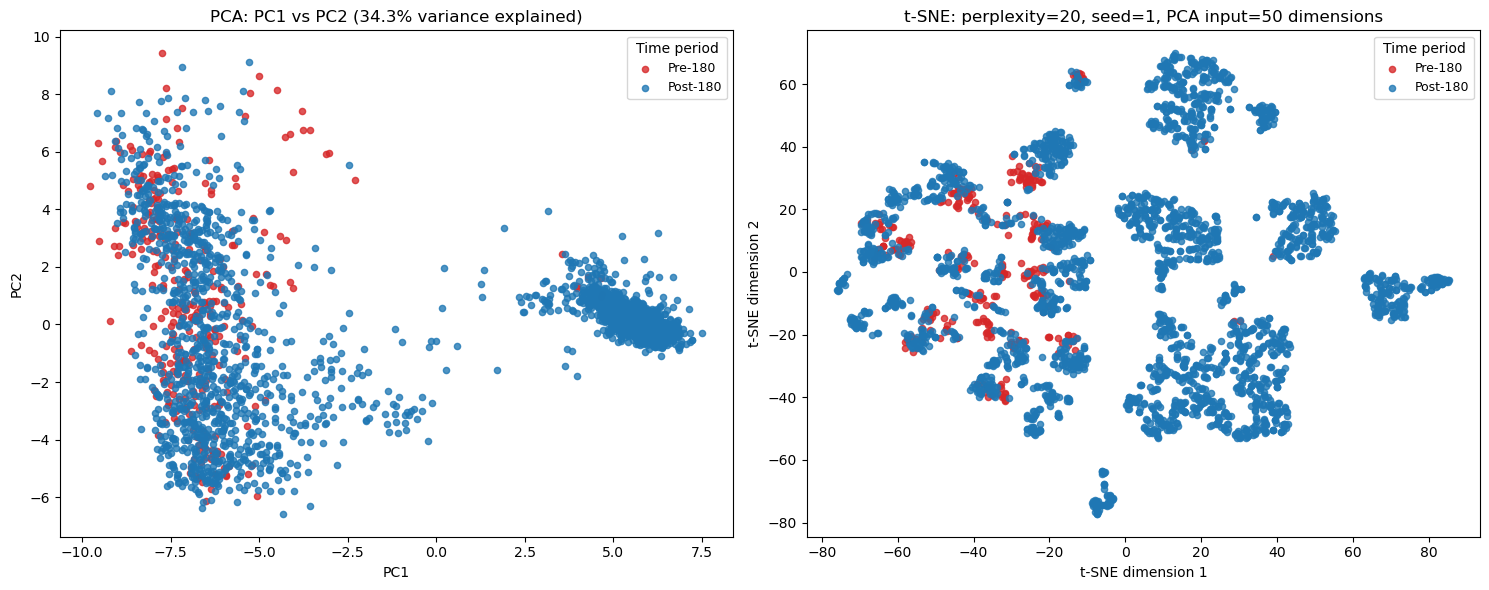

In [6]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import random

sample_limit = 3000
random_state = 42
baseline_perplexity_target = 20
tsne_seed_candidates = [0, 1, 2, 42, 99]

vectors = []
labels = []

# choose metadata field for color coding
# options you likely have: "time_slice", "pred_label", "creator", "type"
color_by = "time_slice"

rng = random.Random(random_state)

def normalize_time_slice(value):
    text = str(value).strip().lower().replace("-", "_")
    if text in {"pre180", "pre_180"}:
        return "pre_180"
    if text in {"post180", "post_180"}:
        return "post_180"
    return str(value)

with h5py.File(path, "r") as f:
    group_names = list(f.keys())
    rng.shuffle(group_names)  # shuffle so sample is not biased toward early (pre_180) texts

    for group_name in group_names:
        g = f[group_name]
        emb_names = [k for k in g.keys() if k.endswith("_embedding")]

        label_value = g.attrs.get(color_by)
        if label_value is None:
            label_value = g.attrs.get("pred_label", "NA")
        label_value = str(label_value)
        if color_by == "time_slice":
            label_value = normalize_time_slice(label_value)

        for emb_name in emb_names:
            vectors.append(g[emb_name][:])
            labels.append(label_value)
            if len(vectors) >= sample_limit:
                break
        if len(vectors) >= sample_limit:
            break

X = np.asarray(vectors, dtype=np.float32)
print("sampled vectors:", X.shape)
from collections import Counter
print("time_slice distribution in sample:", Counter(labels))

if X.shape[0] < 10:
    raise ValueError("Need at least 10 vectors for PCA/t-SNE preview.")

# PCA: reduce to n_pca_components for both plotting (PC1 vs PC2) and t-SNE input
n_pca_components = min(50, X.shape[0], X.shape[1])
pca = PCA(n_components=n_pca_components, random_state=random_state)
X_pca = pca.fit_transform(X)

pc12_var = pca.explained_variance_ratio_[:2].sum()
total_pca_var = pca.explained_variance_ratio_.sum()

print(f"PCA input matrix: {X.shape[0]:,} embeddings × {X.shape[1]} dimensions")
print(f"PCA reduced to {n_pca_components} components, retaining {total_pca_var:.1%} of variance.")
print(f"PC1 + PC2 (left plot) explain {pc12_var:.1%} of variance.")

# Baseline perplexity: fixed target for comparability, capped by sample size
perplexity = min(baseline_perplexity_target, max(2, X_pca.shape[0] - 1))
print(f"t-SNE baseline perplexity: {perplexity} (target={baseline_perplexity_target}, roughly local neighborhood size)")

# Seed stability summary on pre/post subset (if available), then choose median-stability seed for plotting
plot_seed = random_state
labels_arr = np.asarray(labels, dtype=str)
binary_mask = np.isin(labels_arr, ["pre_180", "post_180"])

if binary_mask.sum() >= 10 and len(np.unique(labels_arr[binary_mask])) == 2:
    X_eval = X_pca[binary_mask]
    y_eval = labels_arr[binary_mask]
    eval_perplexity = min(perplexity, max(2, X_eval.shape[0] - 1))

    seed_rows = []
    for seed in tsne_seed_candidates:
        tsne_eval = TSNE(
            n_components=2,
            random_state=seed,
            perplexity=eval_perplexity,
            init="pca",
            learning_rate="auto",
        )
        Y_eval = tsne_eval.fit_transform(X_eval)
        sil = silhouette_score(Y_eval, y_eval)
        seed_rows.append({"seed": seed, "silhouette_tsne": float(sil)})

    seed_df = pd.DataFrame(seed_rows).sort_values("silhouette_tsne").reset_index(drop=True)
    median_sil = seed_df["silhouette_tsne"].median()
    chosen_row = seed_df.iloc[(seed_df["silhouette_tsne"] - median_sil).abs().argmin()]
    plot_seed = int(chosen_row["seed"])

    print("\nSeed stability summary (pre_180/post_180 subset):")
    print(seed_df.to_string(index=False))
    print(f"Median silhouette across seeds: {median_sil:.4f}")
    print(f"Plot seed selected (closest to median silhouette): {plot_seed}")
else:
    print("\nSeed stability summary skipped (need both pre_180 and post_180 with enough points).")
    print(f"Using default plot seed: {plot_seed}")

tsne = TSNE(
    n_components=2,
    random_state=plot_seed,
    perplexity=perplexity,
    init="pca",
    learning_rate="auto",
)
X_tsne = tsne.fit_transform(X_pca)

present_labels = set(labels)
if color_by == "time_slice":
    ordered_base = ["pre_180", "post_180"]
    unique_labels = [label for label in ordered_base if label in present_labels]
    unique_labels += sorted(label for label in present_labels if label not in ordered_base)
    legend_text = {"pre_180": "Pre-180", "post_180": "Post-180"}
    fixed_colors = {"pre_180": "#d62728", "post_180": "#1f77b4"}
else:
    unique_labels = sorted(present_labels)
    legend_text = {label: label for label in unique_labels}
    fixed_colors = {}

label_to_idx = {label: i for i, label in enumerate(unique_labels)}
label_idx = np.array([label_to_idx[lbl] for lbl in labels])
fallback_cmap = plt.cm.get_cmap("tab10", max(1, len(unique_labels)))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: PCA — always PC1 vs PC2 regardless of n_pca_components
for i, label in enumerate(unique_labels):
    mask = label_idx == i
    color = fixed_colors.get(label, fallback_cmap(i))
    axes[0].scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=20,
        alpha=0.78,
        color=color,
        label=legend_text.get(label, label),
    )
axes[0].set_title(f"PCA: PC1 vs PC2 ({pc12_var:.1%} variance explained)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(title="Time period", loc="best", fontsize=9)

# Right: t-SNE (input was all n_pca_components dims)
for i, label in enumerate(unique_labels):
    mask = label_idx == i
    color = fixed_colors.get(label, fallback_cmap(i))
    axes[1].scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        s=20,
        alpha=0.78,
        color=color,
        label=legend_text.get(label, label),
    )
axes[1].set_title(f"t-SNE: perplexity={perplexity}, seed={plot_seed}, PCA input={n_pca_components} dimensions")
axes[1].set_xlabel("t-SNE dimension 1")
axes[1].set_ylabel("t-SNE dimension 2")
axes[1].legend(title="Time period", loc="best", fontsize=9)

plt.tight_layout()
plt.show()

In [7]:
# Validation checks for Cell 7: seed stability, perplexity sensitivity, and class-imbalance effect
from sklearn.metrics import silhouette_score
from collections import Counter

if "X" not in globals() or "labels" not in globals():
    raise RuntimeError("Run Cell 7 first so X and labels are available.")

labels_arr = np.asarray(labels, dtype=str)
valid_mask = np.isin(labels_arr, ["pre_180", "post_180"])
X_eval = X[valid_mask]
y_eval = labels_arr[valid_mask]

print(f"Using {X_eval.shape[0]} vectors with time_slice labels pre_180/post_180.")
print("Label counts:", dict(Counter(y_eval)))

if len(np.unique(y_eval)) < 2:
    raise RuntimeError("Need both pre_180 and post_180 labels for validation checks.")

def _fit_pca(X_in, n_components, seed=42):
    n_comp = min(int(n_components), X_in.shape[0], X_in.shape[1])
    pca_local = PCA(n_components=n_comp, random_state=seed)
    X_pca_local = pca_local.fit_transform(X_in)
    return X_pca_local, n_comp

def _valid_perplexities(n_samples, candidates):
    return [p for p in candidates if 2 <= p < n_samples]

def _tsne_sil(X_pca_local, y, perp, seed):
    tsne_local = TSNE(
        n_components=2,
        random_state=seed,
        perplexity=perp,
        init="pca",
        learning_rate="auto",
    )
    Y = tsne_local.fit_transform(X_pca_local)
    return silhouette_score(Y, y)

# Baseline setup
baseline_pca_target = int(globals().get("n_pca_components", 50))
X_pca_eval, used_pca = _fit_pca(X_eval, baseline_pca_target, seed=42)
baseline_perp = int(globals().get("perplexity", 10))
if baseline_perp >= X_pca_eval.shape[0]:
    baseline_perp = max(2, X_pca_eval.shape[0] // 4)

print(f"Baseline settings -> PCA dims: {used_pca}, perplexity: {baseline_perp}")

# 1) Seed stability
seed_results = []
for seed in [0, 1, 2, 42, 99]:
    sil = _tsne_sil(X_pca_eval, y_eval, baseline_perp, seed=seed)
    seed_results.append({"seed": seed, "perplexity": baseline_perp, "pca_dims": used_pca, "silhouette_tsne": sil})
seed_df = pd.DataFrame(seed_results)

# 2) Perplexity sensitivity (fixed seed)
perp_candidates = _valid_perplexities(X_pca_eval.shape[0], [5, 10, 20, 30])
perp_results = []
for perp in perp_candidates:
    sil = _tsne_sil(X_pca_eval, y_eval, perp, seed=42)
    perp_results.append({"seed": 42, "perplexity": perp, "pca_dims": used_pca, "silhouette_tsne": sil})
perp_df = pd.DataFrame(perp_results)

# 3) Imbalance check via repeated balanced downsampling
class_vals, class_counts = np.unique(y_eval, return_counts=True)
n_min = int(class_counts.min())
balanced_results = []
for rep in range(10):
    rng_local = np.random.default_rng(rep)
    keep_idx = []
    for cls in class_vals:
        cls_idx = np.where(y_eval == cls)[0]
        keep_idx.extend(rng_local.choice(cls_idx, size=n_min, replace=False).tolist())
    keep_idx = np.array(sorted(keep_idx))

    X_bal = X_eval[keep_idx]
    y_bal = y_eval[keep_idx]
    X_bal_pca, bal_pca_dims = _fit_pca(X_bal, baseline_pca_target, seed=42)
    bal_perp = min(baseline_perp, max(2, X_bal_pca.shape[0] - 1))
    sil_bal = _tsne_sil(X_bal_pca, y_bal, bal_perp, seed=42)

    balanced_results.append({
        "rep": rep,
        "n_each_class": n_min,
        "n_total": len(keep_idx),
        "perplexity": bal_perp,
        "pca_dims": bal_pca_dims,
        "silhouette_tsne": sil_bal,
    })
balanced_df = pd.DataFrame(balanced_results)

print("\n=== Seed Stability (fixed perplexity) ===")
display(seed_df)
print(f"Silhouette range across seeds: {seed_df['silhouette_tsne'].min():.4f} to {seed_df['silhouette_tsne'].max():.4f}")

print("\n=== Perplexity Sensitivity (fixed seed=42) ===")
display(perp_df)
if len(perp_df) > 0:
    best_row = perp_df.loc[perp_df['silhouette_tsne'].idxmax()]
    print(f"Best perplexity in tested set: {int(best_row['perplexity'])} (silhouette={best_row['silhouette_tsne']:.4f})")

print("\n=== Balanced Downsampling Check (10 repeats) ===")
display(balanced_df)
print(
    f"Balanced silhouette mean ± sd: "
    f"{balanced_df['silhouette_tsne'].mean():.4f} ± {balanced_df['silhouette_tsne'].std(ddof=1):.4f}"
)

Using 3000 vectors with time_slice labels pre_180/post_180.
Label counts: {np.str_('post_180'): 2685, np.str_('pre_180'): 315}
Baseline settings -> PCA dims: 50, perplexity: 20

=== Seed Stability (fixed perplexity) ===

=== Seed Stability (fixed perplexity) ===


,seed,perplexity,pca_dims,silhouette_tsne
0,0,20,50,0.016146
1,1,20,50,0.016299
2,2,20,50,0.015294
3,42,20,50,0.018889
4,99,20,50,0.017937


Silhouette range across seeds: 0.0153 to 0.0189

=== Perplexity Sensitivity (fixed seed=42) ===


,seed,perplexity,pca_dims,silhouette_tsne
0,42,5,50,0.017326
1,42,10,50,0.014563
2,42,20,50,0.018889
3,42,30,50,0.003038


Best perplexity in tested set: 20 (silhouette=0.0189)

=== Balanced Downsampling Check (10 repeats) ===


,rep,n_each_class,n_total,perplexity,pca_dims,silhouette_tsne
0,0,315,630,20,50,0.261001
1,1,315,630,20,50,0.220494
2,2,315,630,20,50,0.207758
3,3,315,630,20,50,0.234852
4,4,315,630,20,50,0.273860
5,5,315,630,20,50,0.263888
6,6,315,630,20,50,0.226429
7,7,315,630,20,50,0.251777
8,8,315,630,20,50,0.262197
9,9,315,630,20,50,0.237003


Balanced silhouette mean ± sd: 0.2439 ± 0.0218


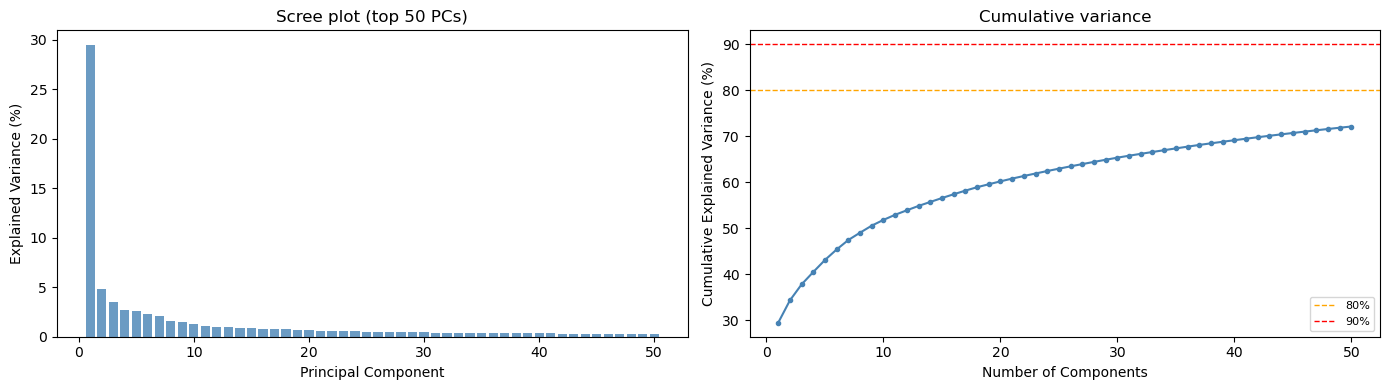

PCs needed for 80% variance: >50 (not reached — increase n_pca_components to find exact number)
PCs needed for 90% variance: >50 (not reached — increase n_pca_components to find exact number)
Current n_pca_components=50 captures 72.1%

Note: for BERT embeddings, needing >50 PCs for 80% is normal.
50 PCs at 72.1% is a solid t-SNE input — no need to go higher unless you see artefacts.


In [8]:
# Scree plot: how much variance does each PC capture?
# The elbow shows where adding more components stops helping much.

evr = pca.explained_variance_ratio_
cumulative = np.cumsum(evr)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: individual variance per component
axes[0].bar(range(1, len(evr) + 1), evr * 100, color="steelblue", alpha=0.8)
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title(f"Scree plot (top {len(evr)} PCs)")

# Right: cumulative variance — useful for picking n_pca_components
axes[1].plot(range(1, len(cumulative) + 1), cumulative * 100, marker="o", markersize=3, color="steelblue")
axes[1].axhline(80, color="orange", linestyle="--", linewidth=1, label="80%")
axes[1].axhline(90, color="red",    linestyle="--", linewidth=1, label="90%")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance (%)")
axes[1].set_title("Cumulative variance")
axes[1].legend(fontsize=8)

# Annotate only if the threshold is actually reached within computed components
for threshold, color in [(0.80, "orange"), (0.90, "red")]:
    idx = np.searchsorted(cumulative, threshold)
    if idx < len(cumulative):
        n_needed = idx + 1
        axes[1].axvline(n_needed, color=color, linestyle=":", linewidth=1)
        axes[1].text(n_needed + 0.3, threshold * 100 - 3, f"{n_needed} PCs", fontsize=8, color=color)

plt.tight_layout()
plt.show()

# Summary — clearly flag when a threshold isn't reached in the computed range
def _pcs_needed(cumulative, threshold):
    idx = np.searchsorted(cumulative, threshold)
    if idx >= len(cumulative):
        return f">{len(cumulative)} (not reached — increase n_pca_components to find exact number)"
    return str(idx + 1)

print(f"PCs needed for 80% variance: {_pcs_needed(cumulative, 0.80)}")
print(f"PCs needed for 90% variance: {_pcs_needed(cumulative, 0.90)}")
print(f"Current n_pca_components={n_pca_components} captures {cumulative[-1]:.1%}")
print(f"\nNote: for BERT embeddings, needing >50 PCs for 80% is normal.")
print(f"50 PCs at {cumulative[-1]:.1%} is a solid t-SNE input — no need to go higher unless you see artefacts.")

In [24]:
# Map each plotted point back to file/sentence context
# Must iterate in the same shuffled order used during sampling
point_rows = []

label_priority = ("label_ridge_youden", "label_ridge_f1", "label_svm_youden", "label_svm_f1", "manual_label")

def _clean_attr_text(value, default="NA"):
    if value is None:
        return default
    text = str(value).strip()
    return text if text else default

def _clean_attr_float(value):
    if value is None:
        return np.nan
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan

def _extract_christian_score(attrs):
    prediction_source = _clean_attr_text(attrs.get("prediction_source"), default="NA").lower()
    source_preferences = []
    if "ridge" in prediction_source:
        source_preferences = [
            ("ridge", "score_ridge_logit"),
            ("svm", "score_svm_logit"),
        ]
    elif "svm" in prediction_source:
        source_preferences = [
            ("svm", "score_svm_logit"),
            ("ridge", "score_ridge_logit"),
        ]
    else:
        source_preferences = [
            ("ridge", "score_ridge_logit"),
            ("svm", "score_svm_logit"),
        ]

    for model_name, logit_key in source_preferences:
        logit_value = _clean_attr_float(attrs.get(logit_key))
        if not np.isnan(logit_value):
            return {
                "christian_logit": logit_value,
                "christian_score_source": model_name,
            }

    return {
        "christian_logit": np.nan,
        "christian_score_source": "NA",
    }

with h5py.File(path, "r") as f:
    point_idx = 0
    for group_name in group_names:  # group_names is the shuffled list from the sampling cell
        g = f[group_name]
        emb_names = [k for k in g.keys() if k.endswith("_embedding")]
        n_matched = int(g.attrs.get("n_matched_words", 0))
        label_value = next(
            (str(g.attrs.get(key)).strip() for key in label_priority if g.attrs.get(key) is not None and str(g.attrs.get(key)).strip()),
            'NA',
        )
        score_info = _extract_christian_score(g.attrs)
        for emb_name in emb_names:
            if point_idx >= len(vectors):
                break
            point_rows.append(
                {
                    "point_idx": point_idx,
                    "group_name": group_name,
                    "embedding_name": emb_name,
                    "creator": _clean_attr_text(g.attrs.get("creator")),
                    "title": _clean_attr_text(g.attrs.get("title")),
                    "file": _clean_attr_text(g.attrs.get("file")),
                    "id": _clean_attr_text(g.attrs.get("id")),
                    "time_slice": _clean_attr_text(g.attrs.get("time_slice")),
                    "pred_label": label_value,
                    "prediction_source": _clean_attr_text(g.attrs.get("prediction_source")),
                    "christian_logit": score_info["christian_logit"],
                    "christian_score_source": score_info["christian_score_source"],
                    "sentence_index": int(g.attrs.get("sentence_index", -1)),
                    "n_matched_words": n_matched,
                    "sentence_text": str(g.attrs.get("sentence_text", "")),
                    "pca_x": float(X_pca[point_idx, 0]),
                    "pca_y": float(X_pca[point_idx, 1]),
                    "tsne_x": float(X_tsne[point_idx, 0]),
                    "tsne_y": float(X_tsne[point_idx, 1]),
                }
            )
            point_idx += 1
        if point_idx >= len(vectors):
            break

points_df = pd.DataFrame(point_rows)

print("points mapped:", len(points_df))
points_df[[
    "point_idx",
    "time_slice",
    "pred_label",
    "christian_logit",
    "sentence_index",
    "n_matched_words",
    "sentence_text",
]].head(10)

points mapped: 3000


,point_idx,time_slice,pred_label,christian_logit,sentence_index,n_matched_words,sentence_text
0,0,post_180,christian,-0.410043,552,1,Simul conspexi Angelum Domini cum gladio ignis...
1,1,post_180,christian,2.984057,491,1,Namque Petro clara iamdudum uoce fatenti Cum D...
2,2,pre_180,non_christian,-2.316399,684,1,"hi domini imperium exequentes , cum ad xx pedu..."
3,3,pre_180,christian,-1.390568,1819,1,"tum uero Oeclides , quamquam iam certa sequent..."
4,4,pre_180,non_christian,-2.589653,33579,1,tutam seruitutem se sub dominis Romanis quam l...
5,5,post_180,non_christian,-3.242209,19,1,Epulisque iam repleto resonet Quirite Thybris ...
6,6,post_180,christian,1.798888,167,1,quin etiam quo saepe uiros mens cauta moneret ...
7,7,post_180,christian,3.498070,301,1,quin potius de domino sollicitudinem habendam ...
8,8,post_180,christian,3.404490,578,1,"Ad euangelicum nunc prouoco , hic quoque occur..."
9,9,pre_180,non_christian,-2.065656,1295,1,quod enim dubitant componere crimen in dominos...


In [25]:
# Inspect nearest contexts around a chosen point in t-SNE space
from IPython.display import HTML, display
import html
import textwrap

def _wrap_sentence_html(text, width=110):
    return "<br>".join(textwrap.wrap(str(text), width=width))

def show_neighbor_contexts(point_index=0, k=8, space="tsne", metric="euclidean"):
    if point_index not in set(points_df["point_idx"]):
        raise ValueError(f"point_index {point_index} not in dataframe")

    metric = metric.lower().strip()
    space = space.lower().strip()

    if metric == "cosine":
        from sklearn.metrics.pairwise import cosine_distances
        center_vec = np.asarray(vectors[point_index], dtype=np.float32).reshape(1, -1)
        coords = np.asarray(vectors, dtype=np.float32)
        dists = cosine_distances(center_vec, coords).ravel()
        x_col, y_col = None, None
    else:
        if space == "tsne":
            x_col, y_col = "tsne_x", "tsne_y"
        elif space == "pca":
            x_col, y_col = "pca_x", "pca_y"
        else:
            raise ValueError("space must be 'tsne' or 'pca'")
        coords = points_df[[x_col, y_col]].values
        center = points_df.loc[points_df["point_idx"] == point_index, [x_col, y_col]].iloc[0].values
        dists = np.sqrt(((coords - center) ** 2).sum(axis=1))

    out = points_df.copy()
    out["distance"] = dists
    out = out.sort_values("distance").head(k)

    cols = [
        "point_idx",
        "distance",
        "time_slice",
        "pred_label",
        "christian_logit",
        "christian_score_source",
        "file",
        "sentence_index",
        "n_matched_words",
        "sentence_text",
    ]
    display_df = out[cols].copy()
    display_df["christian_logit"] = display_df["christian_logit"].apply(
        lambda value: "NA" if pd.isna(value) else f"{value:.3f}"
    )
    display_df["sentence_text"] = display_df["sentence_text"].apply(_wrap_sentence_html)

    html_table = display_df.to_html(index=False, escape=False)
    title = f"Nearest contexts for point_idx={point_index} (metric={metric}"
    if metric != "cosine":
        title += f", space={space}"
    title += ")"
    display(HTML(f"<div style='font-family: monospace; font-size: 12.5px; line-height: 1.45; margin-bottom: 0.5em;'><b>{title}</b></div>"))
    display(HTML(f"<div style='font-family: monospace; font-size: 12.5px; line-height: 1.45;'>{html_table}</div>"))
    return out[cols]

# pick a point index you care about from the scatter and inspect its neighbors
# show_neighbor_contexts(point_index=0, k=10, space="tsne")
show_neighbor_contexts(point_index=0, k=10, metric="cosine")

,point_idx,distance,time_slice,pred_label,christian_logit,christian_score_source,file,sentence_index,n_matched_words,sentence_text
0,0,0.000000,post_180,christian,-0.410043,ridge,lat_0350_IT-LAT0978.txt,552,1,Simul conspexi Angelum Domini cum gladio ignis...
2497,2497,0.064878,post_180,christian,4.672297,ridge,lat_0391_IT-LAT0847.txt,161,1,Quia angelus Domini descendebat secundum tempu...
1309,1309,0.068710,post_180,christian,2.263238,ridge,lat_0550_IT-LAT0783.txt,248,1,"Sic et Herodes rex , dum in apostulos Domini s..."
1483,1483,0.072000,post_180,christian,1.903756,ridge,lat_0382_IT-LAT0001.txt,29,76,surgens coram illis tulit in quo iacebat et ab...
1124,1124,0.072164,post_180,christian,1.903756,ridge,lat_0382_IT-LAT0001.txt,4,264,] et de tribu Gad ciuitates confugii Ramoth in...
2069,2069,0.073185,post_180,christian,1.903756,ridge,lat_0382_IT-LAT0001.txt,27,121,die illa super montem Oliuarum qui est contra ...
399,399,0.073458,post_180,christian,1.903756,ridge,lat_0382_IT-LAT0001.txt,0,384,in principio creauit Deus caelum et terram ter...
1186,1186,0.075546,post_180,christian,1.903756,ridge,lat_0382_IT-LAT0001.txt,4,264,] et de tribu Gad ciuitates confugii Ramoth in...
1067,1067,0.078730,post_180,christian,1.903756,ridge,lat_0382_IT-LAT0001.txt,4,264,] et de tribu Gad ciuitates confugii Ramoth in...
2488,2488,0.079250,post_180,christian,2.263238,ridge,lat_0550_IT-LAT0783.txt,176,1,Hic Salamon aedificauit templum nomini Domini ...


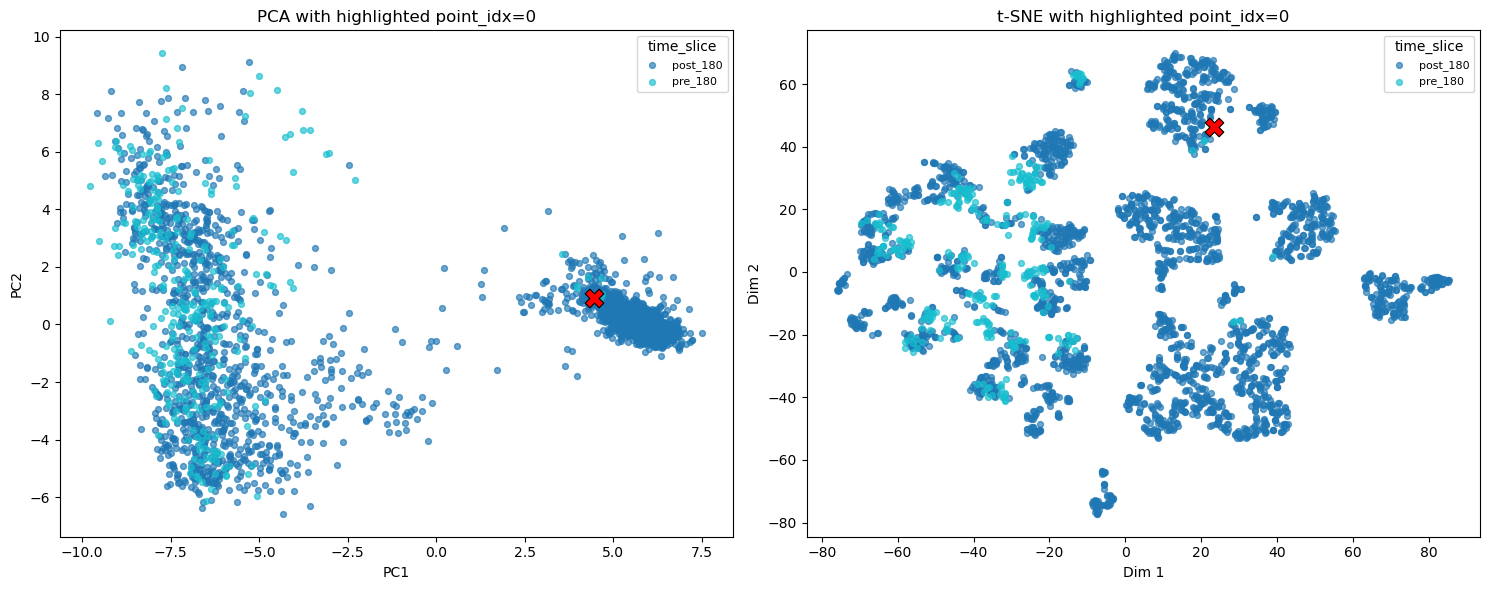

In [26]:
# Highlight a chosen point index on PCA/t-SNE and print its context
from IPython.display import HTML, display
import html
import textwrap

def _format_sentence(text, width=110):
    return "<br>".join(textwrap.wrap(str(text), width=width))

def plot_with_highlight(point_index=0):
    if point_index not in set(points_df["point_idx"]):
        raise ValueError(f"point_index {point_index} not found")

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    unique_labels = sorted(points_df[color_by].astype(str).unique())
    cmap = plt.get_cmap("tab10", max(1, len(unique_labels)))

    for i, label in enumerate(unique_labels):
        mask = points_df[color_by].astype(str) == label
        axes[0].scatter(
            points_df.loc[mask, "pca_x"],
            points_df.loc[mask, "pca_y"],
            s=18,
            alpha=0.65,
            color=cmap(i),
            label=label,
        )

    for i, label in enumerate(unique_labels):
        mask = points_df[color_by].astype(str) == label
        axes[1].scatter(
            points_df.loc[mask, "tsne_x"],
            points_df.loc[mask, "tsne_y"],
            s=18,
            alpha=0.65,
            color=cmap(i),
            label=label,
        )

    row = points_df.loc[points_df["point_idx"] == point_index].iloc[0]

    axes[0].scatter(row["pca_x"], row["pca_y"], s=180, marker="X", color="red", edgecolor="black", linewidth=0.8)
    axes[1].scatter(row["tsne_x"], row["tsne_y"], s=180, marker="X", color="red", edgecolor="black", linewidth=0.8)

    axes[0].set_title(f"PCA with highlighted point_idx={point_index}")
    axes[1].set_title(f"t-SNE with highlighted point_idx={point_index}")

    axes[0].set_xlabel("PC1")
    axes[0].set_ylabel("PC2")
    axes[1].set_xlabel("Dim 1")
    axes[1].set_ylabel("Dim 2")

    axes[0].legend(title=color_by, loc="best", fontsize=8)
    axes[1].legend(title=color_by, loc="best", fontsize=8)

    plt.tight_layout()
    plt.show()

    sentence_html = html.escape(str(row["sentence_text"]))
    sentence_html = _format_sentence(sentence_html, width=110)
    christian_logit_display = "NA" if pd.isna(row["christian_logit"]) else f"{row['christian_logit']:.3f}"
    context_html = f"""
    <div style='font-family: monospace; font-size: 13px; line-height: 1.45;'>
      <div><b>point_idx:</b> {row['point_idx']}</div>
      <div><b>time_slice:</b> {html.escape(str(row['time_slice']))}</div>
      <div><b>pred_label:</b> {html.escape(str(row['pred_label']))}</div>
      <div><b>christian_logit:</b> {html.escape(christian_logit_display)}</div>
      <div><b>score_source:</b> {html.escape(str(row['christian_score_source']))}</div>
      <div><b>file:</b> {html.escape(str(row['file']))}</div>
      <div><b>sentence_index:</b> {row['sentence_index']}</div>
      <div style='margin-top: 0.6em;'><b>sentence_text:</b><br>{sentence_html}</div>
    </div>
    """
    display(HTML(context_html))

# demo
plot_with_highlight(point_index=0)

In [ ]:
# interactive views
# Hover points to read `point_idx`, then use helper functions below.

import plotly.express as px
import textwrap

plot_df = points_df.copy()

# Wrap sentence text to ~60 chars per line, capped at 3 lines
def wrap_sentence(text, width=60, max_lines=3):
    lines = textwrap.wrap(str(text), width=width)
    if len(lines) > max_lines:
        lines = lines[:max_lines]
        lines[-1] = lines[-1][:57] + "..."
    return "<br>".join(lines)

def format_number(value, decimals=3):
    if pd.isna(value):
        return "NA"
    return f"{value:.{decimals}f}"

def build_interactive_scatter(dataframe, x_name, y_name, color_field, title_text):
    fig = px.scatter(
        dataframe,
        x=x_name,
        y=y_name,
        color=color_field,
        hover_name="point_idx",
        custom_data=[
            "time_slice",
            "pred_label",
            "christian_logit_display",
            "score_source_display",
            "creator",
            "title",
            "file",
            "sentence_index_display",
            "sentence_wrapped",
        ],
        title=title_text,
        opacity=0.8,
    )
    fig.update_traces(
        marker=dict(size=8),
        hovertemplate=(
            "<b>point_idx=%{hovertext}</b><br>"
            "Time slice: %{customdata[0]}<br>"
            "Predicted label: %{customdata[1]}<br>"
            "Christian logit: %{customdata[2]}<br>"
            "Score source: %{customdata[3]}<br>"
            "Creator: %{customdata[4]}<br>"
            "Title: %{customdata[5]}<br>"
            "File: %{customdata[6]}<br>"
            "Sentence index: %{customdata[7]}<br>"
            "Sentence: %{customdata[8]}"
            "<extra></extra>"
        ),
    )
    fig.update_layout(
        height=560,
        width=900,
        hoverlabel=dict(
            bgcolor="white",
            font_size=12,
            namelength=-1,
        ),
    )
    return fig

plot_df["sentence_wrapped"] = plot_df["sentence_text"].apply(wrap_sentence)
plot_df["christian_logit_display"] = plot_df["christian_logit"].apply(lambda v: format_number(v, 3))
plot_df["score_source_display"] = plot_df["christian_score_source"].replace({"NA": "unknown"})
plot_df["sentence_index_display"] = plot_df["sentence_index"].astype(str)

tsne_time_slice_fig = build_interactive_scatter(
    plot_df,
    x_name="tsne_x",
    y_name="tsne_y",
    color_field="time_slice",
    title_text="t-SNE plot colored by time slice: hover to get point_idx",
)
tsne_label_fig = build_interactive_scatter(
    plot_df,
    x_name="tsne_x",
    y_name="tsne_y",
    color_field="pred_label",
    title_text="t-SNE plot colored by predicted label: hover to get point_idx",
)
pca_time_slice_fig = build_interactive_scatter(
    plot_df,
    x_name="pca_x",
    y_name="pca_y",
    color_field="time_slice",
    title_text="PCA plot colored by time slice: hover to get point_idx",
)
pca_label_fig = build_interactive_scatter(
    plot_df,
    x_name="pca_x",
    y_name="pca_y",
    color_field="pred_label",
    title_text="PCA plot colored by predicted label: hover to get point_idx",
)

tsne_time_slice_fig.show()
tsne_label_fig.show()
pca_time_slice_fig.show()
pca_label_fig.show()

print("Hover a dot to read point_idx, then run:")
print("  show_neighbor_contexts(point_index=<idx>, k=10, space='tsne')")
print("or:")
print("  plot_with_highlight(point_index=<idx>)")
print("\nInterpretation:")
print("  - Christian logit: the raw signed score from the classifier.")
print("  - Larger values are more Christian-leaning; smaller values are more non-Christian-leaning.")
print("  - The exact classification cutoff depends on the chosen rule (e.g. Youden or F1) and is not stored in this notebook metadata.")

Hover a dot to read point_idx, then run:
  show_neighbor_contexts(point_index=<idx>, k=10, space='tsne')
or:
  plot_with_highlight(point_index=<idx>)

Interpretation:
  - Christian logit: the raw signed score from the classifier.
  - Larger values are more Christian-leaning; smaller values are more non-Christian-leaning.
  - The exact classification cutoff depends on the chosen rule (e.g. Youden or F1) and is not stored in this notebook metadata.


In [ ]:
# Save the interactive Plotly figures as standalone HTML files for browser viewing/sharing
from pathlib import Path

export_dir = base / "plotly_exports"
export_dir.mkdir(parents=True, exist_ok=True)

tsne_time_slice_html = export_dir / f"{path.stem}_tsne_by_time_slice.html"
tsne_label_html = export_dir / f"{path.stem}_tsne_by_pred_label.html"
pca_time_slice_html = export_dir / f"{path.stem}_pca_by_time_slice.html"
pca_label_html = export_dir / f"{path.stem}_pca_by_pred_label.html"

tsne_time_slice_fig.write_html(tsne_time_slice_html, include_plotlyjs="cdn")
tsne_label_fig.write_html(tsne_label_html, include_plotlyjs="cdn")
pca_time_slice_fig.write_html(pca_time_slice_html, include_plotlyjs="cdn")
pca_label_fig.write_html(pca_label_html, include_plotlyjs="cdn")

print("Saved Plotly HTML files:")
print(" -", tsne_time_slice_html)
print(" -", tsne_label_html)
print(" -", pca_time_slice_html)
print(" -", pca_label_html)
print("\nOpen any file in a browser, or upload/share it as a standalone interactive figure.")

Saved Plotly HTML files:
 - /Users/pinkhorse/Documents/GitHub/latinise/christianity_semantic_change/contextual_embeddings/output/single_word_embeddings/plotly_exports/berts_finetuned_full_with_metadata_dominus_tsne_by_time_slice.html
 - /Users/pinkhorse/Documents/GitHub/latinise/christianity_semantic_change/contextual_embeddings/output/single_word_embeddings/plotly_exports/berts_finetuned_full_with_metadata_dominus_tsne_by_pred_label.html

Open either file in a browser, or upload/share it as a standalone interactive figure.


In [13]:
show_neighbor_contexts(point_index=13, k=10, metric="cosine")

point_idx,distance,time_slice,pred_label,christian_score_pct,christian_score_source,file,sentence_index,n_matched_words,sentence_text
13,2.384186e-07,post_180,christian,22.5%,ridge,lat_0158_IT-LAT0043.txt,2295,1,"At ego praecipitante consilium periculi tanti praesentia nec exspectata diutina cogitatione lanienamimminentem fuga uitate statui , protinusque uinculo , quo fueram deligatus , abrupto curso me proripio totispedibus , ad tutelam salutis crebris calcibus uelitatus , ilicoque me raptim transcursa proxima porticutriclinio , in quo dominus aedium sacrificales epulas cum sacerdotibus deae cenitabat , incunctanter immitto ,nec pauca rerum adparatus cibarii mensas etiam et ignes impetu meo collido atque disturbo ."
648,2.952151e-01,post_180,christian,22.5%,ridge,lat_0158_IT-LAT0043.txt,2210,1,"Quam mortem dominus eorum aegerrime sustinens adreptum seruulum , qui causam tanti sceleris luxurie suapraestiterat , nudum ac totum melle perlitum firmiter alligauit arbori ficulneae , cuius in ipso cariosostipite inhabitantium formicarum nidificia bulliebant et ultro citro commeabant multiiuga scaturrigine ."
1253,2.959414e-01,pre_180,non_christian,4.5%,ridge,lat_-0049_IT-LAT0377.txt,2798,1,aedium dominus ?
2025,3.191541e-01,post_180,christian,15.4%,ridge,lat_0350_LC-11.txt,875,1,"si cuius domum hospitii gratia fueris ingressus et dominus domus felicibus subleuatur augmentis , et tuparticeps felicitatis existis ;"
1726,3.242522e-01,post_180,christian,22.5%,ridge,lat_0158_IT-LAT0043.txt,2245,1,hoc enim nomine censebatur iam meus dominus .
1203,3.310225e-01,post_180,christian,15.4%,ridge,lat_0350_LC-11.txt,2769,1,"Quodsi ipse geniturae dominus effectus aut in domo sua sit aut in finibus suis aut in domo Iouis uel infinibus suis aut in domo Solis et sit diurna genitura [ locum ] , faciet in uita claros et nobiles et omnemfelicitatem pro locorum potestate decernit ."
497,3.340292e-01,post_180,christian,45.4%,ridge,lat_0531_IT-LAT0867.txt,68491,3,"Imperatores Arcadius , Honorius In qualibet uel nos ipsi urbe fuerimus uel ii qui nobis militant commorentur ,omni tam mensorum quam etiam hospitum iniquitate submota duas dominus propriae domus , tertia hospiti deputata, eatenus intrepidus ac securus possideat portiones , ut in tres domus diuisae partes primam eligendi dominushabeat facultatem , secundam hospes quam uoluerit exsequatur , tertia domino relinquenda ."
928,3.355510e-01,post_180,christian,22.5%,ridge,lat_0158_IT-LAT0043.txt,2785,1,"Magno denique delibutus gaudio dominus , uocatis seruis suis , emptoribus meis , iubet quadruplum restituipretium meque cuidam acceptissimo liberto suo et satis peculiato magnam praefatus diligentiam tradidit ."
442,3.377175e-01,post_180,christian,45.4%,ridge,lat_0531_IT-LAT0867.txt,63942,1,"ita ut etiam dominus fundi , in quo alienus fuisse monstrabitur , pro qualitate peccati coercitionem subirecogatur nec sit ignorantiae locus , cum ad criminis rationem solum illud sufficiat , quod incognitum sibitenuit . ;"
1557,3.412900e-01,post_180,christian,65.3%,ridge,lat_0350.0_MQDQ-151.txt,1167,1,Tum dominus ruris plures incedere seruos Praecipit et rursum mercedis pacta reposcit ;


,point_idx,distance,time_slice,pred_label,christian_score_pct,christian_score_source,file,sentence_index,n_matched_words,sentence_text
13,13,2.384186e-07,post_180,christian,22.5,ridge,lat_0158_IT-LAT0043.txt,2295,1,At ego praecipitante consilium periculi tanti ...
648,648,2.952151e-01,post_180,christian,22.5,ridge,lat_0158_IT-LAT0043.txt,2210,1,Quam mortem dominus eorum aegerrime sustinens ...
1253,1253,2.959414e-01,pre_180,non_christian,4.5,ridge,lat_-0049_IT-LAT0377.txt,2798,1,aedium dominus ?
2025,2025,3.191541e-01,post_180,christian,15.4,ridge,lat_0350_LC-11.txt,875,1,si cuius domum hospitii gratia fueris ingressu...
1726,1726,3.242522e-01,post_180,christian,22.5,ridge,lat_0158_IT-LAT0043.txt,2245,1,hoc enim nomine censebatur iam meus dominus .
1203,1203,3.310225e-01,post_180,christian,15.4,ridge,lat_0350_LC-11.txt,2769,1,Quodsi ipse geniturae dominus effectus aut in ...
497,497,3.340292e-01,post_180,christian,45.4,ridge,lat_0531_IT-LAT0867.txt,68491,3,"Imperatores Arcadius , Honorius In qualibet ue..."
928,928,3.355510e-01,post_180,christian,22.5,ridge,lat_0158_IT-LAT0043.txt,2785,1,"Magno denique delibutus gaudio dominus , uocat..."
442,442,3.377175e-01,post_180,christian,45.4,ridge,lat_0531_IT-LAT0867.txt,63942,1,"ita ut etiam dominus fundi , in quo alienus fu..."
1557,1557,3.412900e-01,post_180,christian,65.3,ridge,lat_0350.0_MQDQ-151.txt,1167,1,Tum dominus ruris plures incedere seruos Praec...


In [14]:
# Coverage check: how many total embeddings exist vs how many are plotted?
total_embeddings = 0
total_groups = 0

with h5py.File(path, "r") as f:
    total_groups = len(f.keys())
    for group_name in f.keys():
        g = f[group_name]
        total_embeddings += len([k for k in g.keys() if k.endswith("_embedding")])

plotted = len(points_df)
unplotted = total_embeddings - plotted

print(f"Total groups (sentences):  {total_groups}")
print(f"Total embeddings in file:  {total_embeddings}")
print(f"sample_limit:              {sample_limit}")
print(f"Points plotted:            {plotted}")
print(f"Unplotted embeddings:      {unplotted}  ({100*unplotted/total_embeddings:.1f}%)")


Total groups (sentences):  5558
Total embeddings in file:  14272
sample_limit:              3000
Points plotted:            3000
Unplotted embeddings:      11272  (79.0%)


In [15]:
# Time-slice coverage across ALL lemma files
# Shows whether imbalance is a data/production issue or simply word attestation patterns
# Terms like martyr/ecclesia being post_180-only is expected.
# Terms like uirtus/deus/fides being exclusively one slice would signal a production problem.

EXPECT_BOTH_SLICES = {"uirtus", "deus", "fides", "uita", "gloria", "lex", "dominus", "salus"}

rows = []
for h5_path in sorted(base.glob("*.h5")):
    lemma = h5_path.stem.replace("berts_finetuned_full_with_metadata_", "")
    counts = {"pre_180": 0, "post_180": 0, "NA": 0}
    n_groups = 0
    with h5py.File(h5_path, "r") as f:
        n_groups = len(f.keys())
        for gname in f.keys():
            g = f[gname]
            n_words = int(g.attrs.get("n_matched_words", 0))
            ts = str(g.attrs.get("time_slice", "NA"))
            counts[ts] = counts.get(ts, 0) + n_words
    rows.append({
        "lemma": lemma,
        "n_groups": n_groups,
        "pre_180": counts.get("pre_180", 0),
        "post_180": counts.get("post_180", 0),
        "NA": counts.get("NA", 0),
    })

coverage_df = pd.DataFrame(rows).sort_values("lemma").reset_index(drop=True)
coverage_df["total"] = coverage_df["pre_180"] + coverage_df["post_180"] + coverage_df["NA"]
coverage_df["pre_180_%"] = (coverage_df["pre_180"] / coverage_df["total"].replace(0, 1) * 100).round(1)
coverage_df["post_180_%"] = (coverage_df["post_180"] / coverage_df["total"].replace(0, 1) * 100).round(1)

only_post = coverage_df[coverage_df["pre_180"] == 0]["lemma"].tolist()
only_pre  = coverage_df[coverage_df["post_180"] == 0]["lemma"].tolist()

# Flag terms that should appear in both but don't
suspicious = [l for l in only_post + only_pre if l in EXPECT_BOTH_SLICES]

print(f"Lemmas with ONLY post_180 embeddings ({len(only_post)}): {only_post}")
print(f"Lemmas with ONLY pre_180  embeddings ({len(only_pre)}):  {only_pre}")
if suspicious:
    print(f"\n⚠️  SUSPICIOUS (expected in both slices but found in only one): {suspicious}")
else:
    print("\n✓ No unexpected single-slice lemmas among high-priority terms.")
print()
coverage_df[["lemma", "n_groups", "pre_180", "post_180", "pre_180_%", "post_180_%", "total"]]


Lemmas with ONLY post_180 embeddings (0): []
Lemmas with ONLY pre_180  embeddings (0):  []

✓ No unexpected single-slice lemmas among high-priority terms.



,lemma,n_groups,pre_180,post_180,pre_180_%,post_180_%,total
0,altare,90,4,425,0.9,99.1,429
1,ara,1147,718,485,59.7,40.3,1203
2,basilica,343,30,328,8.4,91.6,358
3,beatus,1498,705,960,42.3,57.7,1665
4,berts_pretrained_full_with_metadata_altare,90,4,425,0.9,99.1,429
...,...,...,...,...,...,...,...
101,tenebra,37,16,21,43.2,56.8,37
102,tenebrae,997,464,685,40.4,59.6,1149
103,testamentum,1113,282,1046,21.2,78.8,1328
104,uirtus,5441,3447,2513,57.8,42.2,5960


In [16]:
import unicodedata
from collections import defaultdict

# Use the same metadata filter as the extraction script
metadata_file = Path('/Users/pinkhorse/Documents/GitHub/latinise/christianity_semantic_change/data/latinise_metadata_2026_with_predictions.csv')
lemmatized_dir = Path('/Users/pinkhorse/Documents/GitHub/latinise/christianity_semantic_change/data/new_lemmatized_texts')

metadata_df = pd.read_csv(metadata_file)
metadata_df['date_range_end'] = pd.to_numeric(metadata_df['date_range_end'], errors='coerce')
metadata_df = metadata_df.dropna(subset=['date_range_end'])
metadata_df['date_range_end'] = metadata_df['date_range_end'].astype(int)
metadata_ph = metadata_df[
    (metadata_df['date_range_end'] > -300) &
    (metadata_df['date_range_end'] <= 605)
].copy()

# Only files that actually exist in the lemmatized dir and passed the filter
in_scope_files = {
    row['file'] for _, row in metadata_ph.iterrows()
    if (lemmatized_dir / row['file']).exists()
}
print(f"Total lemmatized files on disk: {len(list(lemmatized_dir.glob('*.txt')))}")
print(f"Texts passing metadata filter (date > -300 and <= 605): {len(metadata_ph)}")
print(f"Of those, files found in lemmatized_dir: {len(in_scope_files)}\n")

TARGET_LEMMAS = {
    "altare", "ara", "basilica", "beatus", "caritas", "caro", "codex",
    "communico", "communio", "confessio", "confiteor", "conuersio", "conuerto",
    "credo", "cultus", "culpa", "deus", "disciplina", "dominus",
    "fidelis", "fides", "gentilis", "gens", "gloria", "gratia", "lectio",
    "lex", "lux", "lumen", "mors", "mundus", "mysterium",
    "oratio", "ordo", "paenitentia", "paganus", "passio", "peccatum", "pontifex",
    "regula", "religio", "sacramentum", "salus", "saluator", "saluo", "saeculum",
    "sanctus", "scriptura", "spiritus", "tenebrae", "templum", "testamentum",
    "uita", "uirtus",
}

def normalize_lemma(token):
    if token is None:
        return ""
    normalized = unicodedata.normalize("NFKD", token)
    normalized = "".join(ch for ch in normalized if ch.isalpha())
    normalized = normalized.lower().replace("v", "u")
    return normalized

normalized_targets = {normalize_lemma(t) for t in TARGET_LEMMAS}

corpus_counts = defaultdict(int)
for fname in sorted(in_scope_files):
    with open(lemmatized_dir / fname, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            for token in line.split():
                norm = normalize_lemma(token)
                if norm in normalized_targets:
                    corpus_counts[norm] += 1

print(f"Counted tokens across {len(in_scope_files)} in-scope lemmatized files.\n")

# Build comparison table
compare_rows = []
for lemma in sorted(TARGET_LEMMAS):
    norm = normalize_lemma(lemma)
    corpus_n = corpus_counts.get(norm, 0)
    h5_total = None
    if 'coverage_df' in dir():
        match = coverage_df[coverage_df["lemma"] == lemma]
        h5_total = int(match["total"].iloc[0]) if len(match) > 0 else 0
    compare_rows.append({
        "lemma": lemma,
        "corpus_count": corpus_n,
        "h5_embeddings": h5_total,
    })

compare_df = pd.DataFrame(compare_rows)
if compare_df["h5_embeddings"].notna().any():
    compare_df["coverage_%"] = (compare_df["h5_embeddings"] / compare_df["corpus_count"].replace(0, 1) * 100).round(1)
    compare_df["missing"] = compare_df["corpus_count"] - compare_df["h5_embeddings"]

compare_df.sort_values("corpus_count", ascending=False).reset_index(drop=True)


Total lemmatized files on disk: 1153
Texts passing metadata filter (date > -300 and <= 605): 777
Of those, files found in lemmatized_dir: 777

Counted tokens across 777 in-scope lemmatized files.

Counted tokens across 777 in-scope lemmatized files.



,lemma,corpus_count,h5_embeddings,coverage_%,missing
0,deus,19979,20966,104.9,-987
1,dominus,14123,14272,101.1,-149
2,lex,7697,7606,98.8,91
3,credo,7285,7564,103.8,-279
4,uita,7254,7279,100.3,-25
5,mors,6466,6463,100.0,3
6,uirtus,5955,5960,100.1,-5
7,fides,5946,5916,99.5,30
8,gens,5185,5150,99.3,35
9,sanctus,4346,4258,98.0,88


In [17]:
# Check for duplicate embeddings caused by append-mode re-runs
# If a group has n_matched_words=N but more than N embedding datasets, it was written multiple times

print("Checking for duplicate embeddings in H5 files...\n")
dup_rows = []
for h5_path in sorted(base.glob("*.h5")):
    lemma = h5_path.stem.replace("berts_finetuned_full_with_metadata_", "")
    n_dup_groups = 0
    total_extra = 0
    with h5py.File(h5_path, "r") as f:
        for gname in f.keys():
            g = f[gname]
            n_matched = int(g.attrs.get("n_matched_words", 0))
            n_datasets = len([k for k in g.keys() if k.endswith("_embedding")])
            if n_datasets > n_matched:
                n_dup_groups += 1
                total_extra += n_datasets - n_matched
    if n_dup_groups > 0:
        dup_rows.append({"lemma": lemma, "groups_with_duplicates": n_dup_groups, "extra_embeddings": total_extra})

if dup_rows:
    dup_df = pd.DataFrame(dup_rows).sort_values("extra_embeddings", ascending=False)
    print(f"⚠️  {len(dup_df)} files have groups with extra (duplicate) embeddings:")
    print(dup_df.to_string(index=False))
else:
    print("✓ No duplicate embeddings found.")


Checking for duplicate embeddings in H5 files...

✓ No duplicate embeddings found.
✓ No duplicate embeddings found.


In [18]:
# Cluster contextual embeddings for the currently selected lemma file,
# separately by time slice, then map each cluster centroid to nearest average lemma embeddings.

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

def _normalize_time_slice(value):
    text = str(value).strip().lower().replace("-", "_")
    if text in {"pre180", "pre_180"}:
        return "pre_180"
    if text in {"post180", "post_180"}:
        return "post_180"
    return text

def _extract_embeddings_by_time_slice(h5_path):
    by_slice = {}
    with h5py.File(h5_path, "r") as f:
        for group_name in f.keys():
            g = f[group_name]
            time_slice = _normalize_time_slice(g.attrs.get("time_slice", "NA"))
            emb_names = [k for k in g.keys() if k.endswith("_embedding")]
            if time_slice not in by_slice:
                by_slice[time_slice] = []
            for emb_name in emb_names:
                by_slice[time_slice].append(g[emb_name][:])

    out = {}
    for time_slice, vectors_local in by_slice.items():
        if vectors_local:
            out[time_slice] = np.asarray(vectors_local, dtype=np.float32)
    return out

def optimal_num_clusters(emb_matrix, min_k=2, max_k=10, random_state=0):
    n_samples = emb_matrix.shape[0]
    if n_samples < 3:
        raise ValueError("Need at least 3 embeddings to estimate cluster count.")

    max_k = min(max_k, n_samples - 1)
    if min_k > max_k:
        raise ValueError(f"Invalid k range after size check: min_k={min_k}, max_k={max_k}, n_samples={n_samples}")

    best_k = None
    best_score = -1.0
    for k in range(min_k, max_k + 1):
        model = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
        labels_local = model.fit_predict(emb_matrix)
        if len(np.unique(labels_local)) < 2:
            continue
        score = silhouette_score(emb_matrix, labels_local, metric="euclidean")
        if score > best_score:
            best_k = k
            best_score = score

    if best_k is None:
        raise RuntimeError("Could not compute a valid silhouette score for any k in range.")

    return best_k, best_score

def build_average_embeddings_by_lemma(h5_dir):
    avg = {}
    for h5_path in sorted(h5_dir.glob("berts_finetuned_full_with_metadata_*.h5")):
        lemma = h5_path.stem.replace("berts_finetuned_full_with_metadata_", "")
        running_sum = None
        count = 0
        with h5py.File(h5_path, "r") as f:
            for group_name in f.keys():
                g = f[group_name]
                emb_names = [k for k in g.keys() if k.endswith("_embedding")]
                for emb_name in emb_names:
                    vec = g[emb_name][:].astype(np.float64, copy=False)
                    if running_sum is None:
                        running_sum = np.zeros_like(vec, dtype=np.float64)
                    running_sum += vec
                    count += 1
        if running_sum is not None and count > 0:
            avg[lemma] = (running_sum / count).astype(np.float32)
    if not avg:
        raise ValueError(f"No average embeddings were built from {h5_dir}")
    return avg

def find_neighbors_for_embedding(embedding, average_embeddings, top_k=10, exclude_word=None):
    words = []
    vectors_local = []
    for lemma, vec in average_embeddings.items():
        if exclude_word is not None and lemma == exclude_word:
            continue
        words.append(lemma)
        vectors_local.append(vec)

    if not vectors_local:
        raise ValueError("No candidate lemma embeddings available for neighbor search.")

    all_embeddings = np.asarray(vectors_local, dtype=np.float32)
    sims = cosine_similarity(embedding.reshape(1, -1), all_embeddings).ravel()
    order = np.argsort(-sims)[:top_k]
    return [(words[i], float(sims[i])) for i in order]

word = path.stem.replace("berts_finetuned_full_with_metadata_", "")
print(f"Word: {word}")

# 1) Extract contextual embeddings split by time slice
embeddings_by_slice = _extract_embeddings_by_time_slice(path)
if not embeddings_by_slice:
    raise ValueError(f"No embeddings found in {path.name}")

print("Embeddings per time slice:")
for ts in sorted(embeddings_by_slice):
    print(f"  {ts}: {embeddings_by_slice[ts].shape}")

# 2) Build (or reuse) average lemma embeddings across all available lemma H5 files
if "average_embeddings_all" not in globals() or not isinstance(average_embeddings_all, dict) or len(average_embeddings_all) == 0:
    average_embeddings_all = build_average_embeddings_by_lemma(base)
    print(f"Built average embeddings for {len(average_embeddings_all)} lemmas.")
else:
    print(f"Reusing cached average embeddings for {len(average_embeddings_all)} lemmas.")

# 3) Cluster each target time slice separately
target_slices = ["pre_180", "post_180"]

for time_slice in target_slices:
    print(f"\n{'='*68}")
    print(f"Time slice: {time_slice}")
    print(f"{'='*68}")

    if time_slice not in embeddings_by_slice:
        print("No embeddings found for this slice. Skipping.")
        continue

    embeddings = embeddings_by_slice[time_slice]
    n_samples = embeddings.shape[0]
    print(f"Embeddings shape: {embeddings.shape}")

    if n_samples < 3:
        print("Too few embeddings (<3) to cluster robustly. Skipping.")
        continue

    min_k = 2
    max_k = min(10, n_samples - 1)

    try:
        best_k, best_score = optimal_num_clusters(
            embeddings,
            min_k=min_k,
            max_k=max_k,
            random_state=0,
        )
    except Exception as exc:
        print(f"Could not select k for this slice: {exc}")
        continue

    print(f"Optimal number of clusters for '{word}' [{time_slice}]: {best_k}, silhouette score: {best_score:.4f}")

    kmeans = KMeans(n_clusters=best_k, random_state=0, n_init="auto")
    cluster_labels = kmeans.fit_predict(embeddings)
    cluster_centroids = kmeans.cluster_centers_

    cluster_sizes = pd.Series(cluster_labels).value_counts().sort_index()
    print("Cluster sizes:")
    print(cluster_sizes.to_string())

    for i, centroid in enumerate(cluster_centroids):
        neighbors = find_neighbors_for_embedding(
            centroid,
            average_embeddings_all,
            top_k=10,
            exclude_word=None,
        )
        print(f"\nCluster {i + 1} neighbors for '{word}' [{time_slice}]:")
        for neighbor, sim in neighbors:
            print(f"  {neighbor}: {sim:.4f}")

Word: dominus
Embeddings per time slice:
  post_180: (13130, 768)
  pre_180: (1142, 768)
Embeddings per time slice:
  post_180: (13130, 768)
  pre_180: (1142, 768)
Built average embeddings for 53 lemmas.

Time slice: pre_180
Embeddings shape: (1142, 768)
Built average embeddings for 53 lemmas.

Time slice: pre_180
Embeddings shape: (1142, 768)
Optimal number of clusters for 'dominus' [pre_180]: 2, silhouette score: 0.0760
Cluster sizes:
0    445
1    697

Cluster 1 neighbors for 'dominus' [pre_180]:
  cultus: 0.7661
  mundus: 0.7249
  gentilis: 0.7064
  templum: 0.7046
  credo: 0.7026
  sanctus: 0.7011
  mysterium: 0.6895
  culpa: 0.6890
  uita: 0.6886
  tenebrae: 0.6881

Cluster 2 neighbors for 'dominus' [pre_180]:
  dominus: 0.7647
  gentilis: 0.7631
  credo: 0.7556
  confessio: 0.7524
  cultus: 0.7459
  fidelis: 0.7448
  sacramentum: 0.7448
  religio: 0.7412
  confiteor: 0.7355
  regula: 0.7349

Time slice: post_180
Embeddings shape: (13130, 768)
Optimal number of clusters for 'domi